In [1]:
import sys
import os
import logging
import gc
import time
import torch
import warnings
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as pltSAvFRAb6tEi9UcN
from gliner import GLiNER
from gliner.data_processing.collator import DataCollator
from gliner.training import Trainer, TrainingArguments
from transformers import TrainerCallback
from peft import LoraConfig, get_peft_model, TaskType,PeftModel

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
sys.path

/opt/app/notebooks/abhishek/active_gliner/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['/root/.local/share/uv/python/cpython-3.11.9-linux-x86_64-gnu/lib/python311.zip',
 '/root/.local/share/uv/python/cpython-3.11.9-linux-x86_64-gnu/lib/python3.11',
 '/root/.local/share/uv/python/cpython-3.11.9-linux-x86_64-gnu/lib/python3.11/lib-dynload',
 '',
 '/opt/app/notebooks/abhishek/active_gliner/.venv/lib/python3.11/site-packages',
 '/tmp/tmpgsozfbng']

In [2]:
src_path=os.path.join(os.path.dirname(os.getcwd()),'src')
sys.path.append(src_path)
sys.path


['/root/.local/share/uv/python/cpython-3.11.9-linux-x86_64-gnu/lib/python311.zip',
 '/root/.local/share/uv/python/cpython-3.11.9-linux-x86_64-gnu/lib/python3.11',
 '/root/.local/share/uv/python/cpython-3.11.9-linux-x86_64-gnu/lib/python3.11/lib-dynload',
 '',
 '/opt/app/notebooks/abhishek/active_gliner/.venv/lib/python3.11/site-packages',
 '/tmp/tmpgsozfbng',
 '/opt/app/notebooks/abhishek/active_gliner/src']

In [3]:
from config.settings import Settings
settings = Settings()

print(f"Settings cache_dir: {settings.cache_dir}")
print(f"Cache absolute path: {settings.cache_dir.resolve()}")
print(f"Does cache dir contain 'notebooks': {'notebooks' in str(settings.cache_dir)}")
settings

Settings cache_dir: /opt/app/notebooks/abhishek/active_gliner/cache
Cache absolute path: /opt/app/notebooks/abhishek/active_gliner/cache
Does cache dir contain 'notebooks': True


Settings(seed=42, batch_size=8, model=knowledgator/modern-gliner-bi-large-v1.0)

In [4]:
print("=== Integration Test ===")
from utils.logging import setup_logging
from utils.reproducibility import set_all_seeds
from utils.device import setup_device

# Complete setup like your original code
settings = Settings()
settings.setup()  # Apply environment and create directories

logger = setup_logging(log_dir=str(settings.logs_dir))
set_all_seeds(seed=settings.global_seed, logger=logger)
device = setup_device(logger=logger)

logger.info("All modules integrated successfully!")
print(f"Final setup: seed={settings.global_seed}, device={device}, batch_size={settings.batch_size}")



INFO:ActiveLearning:================================================================================
INFO:ActiveLearning:ACTIVE LEARNING PIPELINE WITH PROPER TRAIN/TEST SEPARATION
INFO:ActiveLearning:================================================================================
INFO:ActiveLearning:Log file: /opt/app/notebooks/abhishek/active_gliner/logs/active_learning_20250916_133119.log
INFO:ActiveLearning:Setting all seeds to 42 for reproducibility...
INFO:ActiveLearning:Using device: cuda
INFO:ActiveLearning:CUDA version: 12.8
INFO:ActiveLearning:Number of GPUs visible: 1
INFO:ActiveLearning:Current GPU: 0
INFO:ActiveLearning:GPU Name: NVIDIA GeForce RTX 3090
INFO:ActiveLearning:GPU Memory: 23.6 GB
INFO:ActiveLearning:All modules integrated successfully!


=== Integration Test ===
Final setup: seed=42, device=cuda, batch_size=8


In [5]:
from data.loader import load_mit_dataset, load_dataset_from_config
from data.transforms import get_ner_statistics, log_ner_statistics  # Stats moved here
from config.settings import settings
from utils.logging import setup_logging

print("=== Testing Data Loader ===")

# Setup logger for testing
logger = setup_logging(log_dir="../logs", logger_name="DataTest")

# Test with dummy data (since actual files might not exist)

# Try to load real data if available
train_data_path = settings.data_path / settings.train_file
test_data_path = settings.data_path / settings.test_file
labels_path = settings.data_path / settings.labels_file

if test_data_path.exists() and labels_path.exists():
    train_data, entity_types = load_mit_dataset(str(train_data_path), str(labels_path), "test")
    print(f"Loaded train real data: {len(train_data)} examples, {len(entity_types)} entity types")
    test_data, entity_types = load_mit_dataset(str(test_data_path), str(labels_path), "test")
    print(f"Loaded test real data: {len(test_data)} examples, {len(entity_types)} entity types")
    

    # train unified stats function (no duplication now)
    stats = get_ner_statistics(train_data, entity_types)
    print(f"Dataset stats: {stats}")
    
    # Log stats using unified function
    log_ner_statistics(test_data, "train", logger, entity_types)



    # Test unified stats function (no duplication now)
    stats = get_ner_statistics(test_data, entity_types)
    print(f"Dataset stats: {stats}")
    
    # Log stats using unified function
    log_ner_statistics(test_data, "test", logger, entity_types)


INFO:DataTest:================================================================================
INFO:DataTest:ACTIVE LEARNING PIPELINE WITH PROPER TRAIN/TEST SEPARATION
INFO:DataTest:================================================================================
INFO:DataTest:Log file: ../logs/active_learning_20250916_133122.log


INFO:DataTest:train Dataset Statistics:
INFO:DataTest:  Total examples: 2442
INFO:DataTest:  Avg num tokens: 10.10
INFO:DataTest:  Avg num entities: 2.15
INFO:DataTest:  Total entities: 5243
INFO:DataTest:  Unique entity types: 12
INFO:DataTest:  Top entity types: [('genre', 1117), ('actor', 812), ('year', 720), ('title', 561), ('plot', 491)]
INFO:DataTest:test Dataset Statistics:
INFO:DataTest:  Total examples: 2442
INFO:DataTest:  Avg num tokens: 10.10
INFO:DataTest:  Avg num entities: 2.15
INFO:DataTest:  Total entities: 5243
INFO:DataTest:  Unique entity types: 12
INFO:DataTest:  Top entity types: [('genre', 1117), ('actor', 812), ('year', 720), ('title', 561), ('plot', 491)]


=== Testing Data Loader ===
Loading test data from: /opt/app/notebooks/abhishek/active_gliner/data/mit-movie/train.json
Processed 9774 examples
Entity types: ['genre', 'year', 'plot', 'average ratings', 'actor', 'title', 'song', 'character', 'rating', 'review', 'director', 'trailer']
Loaded train real data: 9774 examples, 12 entity types
Loading test data from: /opt/app/notebooks/abhishek/active_gliner/data/mit-movie/test.json
Processed 2442 examples
Entity types: ['genre', 'year', 'plot', 'average ratings', 'actor', 'title', 'song', 'character', 'rating', 'review', 'director', 'trailer']
Loaded test real data: 2442 examples, 12 entity types
Dataset stats: {'total_examples': 9774, 'avg_num_tokens': 10.17792101493759, 'avg_num_entities': 2.143953345610804, 'total_entities': 20955, 'unique_entity_types': 12, 'entity_type_counts': Counter({'genre': 4354, 'actor': 3220, 'year': 2858, 'title': 2376, 'plot': 1927, 'average ratings': 1866, 'director': 1720, 'rating': 1671, 'character': 384, '

In [6]:

print("=== Testing Evaluation Evaluator ===")

def intialize_model():



    model = GLiNER.from_pretrained("knowledgator/modern-gliner-bi-large-v1.0")
    model.config.max_len = 8192

    if hasattr(model.data_processor, 'transformer_tokenizer'):    
        model.data_processor.transformer_tokenizer.model_max_length = 8192

    # Get base parameter count
    base_total = sum(p.numel() for p in model.model.parameters())
    logger.info(f"Base Parameters: {base_total:,}")

    print("\n🔧 Applying FIXED LoRA Configuration...")

    # FIXED LoRA config - back to user's preferred values
    lora_config = LoraConfig(
        r=32,               # Back to 32 as requested
        lora_alpha=64,      # Back to 64 as requested
        target_modules=[
            # "query_proj", 
            # "key_proj",
            # "value_proj",
            "dense",
            "projection",
            "Wqkv", "Wo", "Wi",
            #   "linear_1", "linear_2",
            "query", "key", "value",  # BERT attention
        "intermediate.dense", "output.dense",  # BERT MLP,
        
        "span_rep_layer.span_rep_layer.project_start.3","span_rep_layer.span_rep_layer.project_start.0",
        "span_rep_layer.span_rep_layer.project_end.3","span_rep_layer.span_rep_layer.project_end.0",
        "span_rep_layer.span_rep_layer.out_project.3","span_rep_layer.span_rep_layer.out_project.0",
        'prompt_rep_layer.3','prompt_rep_layer.0',
        

        ],
        modules_to_save=[
                # "span_rep_layer",
            # "prompt_rep_layer"   # Only this one works properly
        ],
        lora_dropout=0.1,   # Reduced from 0.2
        bias="none",
        task_type=TaskType.TOKEN_CLS
    )

    # Apply LoRA
    model.model = get_peft_model(model.model, lora_config)

    # Manually make span_rep_layer trainable
    # for param in model.model.base_model.span_rep_layer.parameters():
    #     param.requires_grad = True

    print("✅ LoRA applied successfully!")

    # Get LoRA parameter count
    lora_trainable = sum(p.numel() for p in model.model.parameters() if p.requires_grad)
    print(f"📊 Trainable Parameters: {lora_trainable:,} ({100*lora_trainable/base_total:.1f}% of original)")

    model.to(device)

    print("Model after lora")
    
    return model

model=intialize_model()
display(model)

=== Testing Evaluation Evaluator ===


Fetching 9 files: 100%|██████████| 9/9 [00:00<00:00, 45425.68it/s]
INFO:DataTest:Base Parameters: 529,845,248



🔧 Applying FIXED LoRA Configuration...
✅ LoRA applied successfully!
📊 Trainable Parameters: 20,815,872 (3.9% of original)
Model after lora


GLiNER(
  (model): PeftModelForTokenClassification(
    (base_model): LoraModel(
      (model): SpanModel(
        (token_rep_layer): BiEncoder(
          (bert_layer): Transformer(
            (model): ModernBertModel(
              (embeddings): ModernBertEmbeddings(
                (tok_embeddings): Embedding(50368, 1024, padding_idx=50283)
                (norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
                (drop): Dropout(p=0.0, inplace=False)
              )
              (layers): ModuleList(
                (0): ModernBertEncoderLayer(
                  (attn_norm): Identity()
                  (attn): ModernBertAttention(
                    (Wqkv): lora.Linear(
                      (base_layer): Linear(in_features=1024, out_features=3072, bias=False)
                      (lora_dropout): ModuleDict(
                        (default): Dropout(p=0.1, inplace=False)
                      )
                      (lora_A): ModuleDict(
                   

In [7]:
from evaluation.evaluator import enhanced_evaluate

from data.loader import load_json_file


model.eval()
model.to('cuda')
with torch.no_grad():
    train_results=enhanced_evaluate(model,train_data,entity_types,threshold=0.5,batch_size=8,has_ground_truth=True,logger=logger)



print(train_results['overall_metrics']['overall_f1_pct'])

INFO:DataTest:Running enhanced evaluation...
INFO:DataTest:Processing 9774 examples...


INFO:DataTest:Analyzing errors with ground truth...


47.77759094221176


In [8]:
# ===============================================================================
# 3. Simple Training Monitor with Resource Tracking
# ===============================================================================

class SimpleTrainingMonitor(TrainerCallback):
    """Simple training monitor with resource tracking"""
    
    def __init__(self, patience=10):
        self.train_losses = []
        self.eval_losses = []
        self.learning_rates = []
        self.steps = []
        self.eval_steps = []
        self.patience = patience
        self.best_loss = float('inf')
        self.patience_counter = 0
        
        # Resource trackingPeftModel
        self.gpu_memory = []
        self.cpu_memory = []
        self.timestamps = []
        self.start_time = time.time()
        
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None:
            if 'loss' in logs:
                self.train_losses.append(logs['loss'])
                self.steps.append(state.global_step)
                
                # Track resources
                current_time = (time.time() - self.start_time) / 60  # minutes
                self.timestamps.append(current_time)
                
                if torch.cuda.is_available():
                    gpu_mem = torch.cuda.memory_allocated() / 1024**3  # GB
                    self.gpu_memory.append(gpu_mem)
                
                cpu_mem = psutil.virtual_memory().percent
                self.cpu_memory.append(cpu_mem)
                
            if 'learning_rate' in logs:
                self.learning_rates.append(logs['learning_rate'])

    def on_step_begin(self, args, state, control, **kwargs):
      if state.global_step % 50 == 0:  # Every 50 steps
          torch.cuda.empty_cache()
          gc.collect()
    
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is not None and 'eval_loss' in metrics:
            eval_loss = metrics['eval_loss']
            
            # Check for NaN - CRITICAL FIX
            if np.isnan(eval_loss) or np.isinf(eval_loss):
                print(f"🚨 NaN validation loss detected! Stopping training.")
                control.should_training_stop = True
                return
                
            self.eval_losses.append(eval_loss)
            self.eval_steps.append(state.global_step)
            
            if eval_loss < self.best_loss:
                self.best_loss = eval_loss
                self.patience_counter = 0
                print(f"🎯 New best validation loss: {eval_loss:.4f}")
            else:
                self.patience_counter += 1
                print(f"📈 Validation loss: {eval_loss:.4f} | Patience: {self.patience_counter}/{self.patience}")
                
            if self.patience_counter >= self.patience:
                print("🛑 Early stopping triggered!")
                control.should_training_stop = True

# ===============================================================================
# 4. FIXED Training Configuration
# ===============================================================================

print("\n⚙️ FIXED Training Configuration...")

# FIXED training config - conservative but with user's preferred LR
training_config = {
    'num_steps': 1000,           # Reduced for stability
    'train_batch_size': 8,       # Increased batch size
    'gradient_accumulation_steps': 1,  # Reduced accumulation
    'learning_rate': 0.00021008343694753508,       # Starting with 1 as requested - conservative
    'others_lr': 0.00021008343694753508,           # Even lower for LoRA params
    'warmup_ratio': 0.07064690788186724,        # Longer warmup
    'eval_steps': 100,            # More frequent evaluation
    'save_steps': 100,
    'logging_steps': 10,         # More frequent logging
    'patience': 5,              # More patience
    'max_grad_norm': 1,        # CRITICAL: Gradient clipping
}

print(f"📋 Effective batch size: {training_config['train_batch_size'] * training_config['gradient_accumulation_steps']}")
print(f"📋 Total training steps: {training_config['num_steps']}")
print(f"🔥 CRITICAL FIXES APPLIED:")
print(f"   • Learning rate: {training_config['learning_rate']} (conservative)")
print(f"   • LoRA r: 32, alpha: 64 (as requested)")
# print(f"   • Gradient clipping: {training_config['max_grad_norm']}")
print(f"   • FP16: DISABLED for stability")

# Setup data collator
data_collator = DataCollator(
    model.config, 
    data_processor=model.data_processor, 
    prepare_labels=True
)

# Initialize training monitor
monitor = SimpleTrainingMonitor(patience=training_config['patience'])

# FIXED Training arguments
training_args = TrainingArguments(
    output_dir="../models/corr_syn_model_{i}/corr_syn_model_{j}",
    learning_rate=training_config['learning_rate'],    # FIXED: Much lower
    weight_decay=0.020216630535603918,                                # Reduced weight decay
    others_lr=training_config['others_lr'],            # FIXED: Much lower
    others_weight_decay=0.020216630535603918,
    lr_scheduler_type="cosine",                        # Changed from linear
    warmup_ratio=training_config['warmup_ratio'],
    per_device_train_batch_size=training_config['train_batch_size'],
    per_device_eval_batch_size=training_config['train_batch_size'],
    gradient_accumulation_steps=training_config['gradient_accumulation_steps'],
    max_steps=training_config['num_steps'],
    max_grad_norm=training_config['max_grad_norm'],    # CRITICAL: Added gradient clipping
    
    # FIXED focal loss - much more conservative
    focal_loss_alpha=0.75,      
    focal_loss_gamma=1.0,       
    
    eval_strategy="steps",
    eval_steps=training_config['eval_steps'],
    save_steps=training_config['save_steps'],
    save_total_limit=3,
    logging_steps=training_config['logging_steps'],
    seed=42,
    dataloader_num_workers=0,   # Reduced workers
    use_cpu=False,
    report_to="none",
    
    # CRITICAL: Disabled FP16 for numerical stability
    fp16=False,                 # Was True - causing NaN
    bf16=False,
    
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

# ===============================================================================
# 5. Training Execution
# ===============================================================================

# print(f"\n🚀 Starting FIXED MIT movie LoRA Fine-tuning...")
# print(f"🎬 Training on {len(syn_train)} movie examples")
# print("-" * 60)

# Clear cache before training
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

# Create trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=syn_train,
#     eval_dataset=syn_val,
#     tokenizer=model.data_processor.transformer_tokenizer,
#     data_collator=data_collator,
#     callbacks=[monitor],
# )

# Start training
# train_result = trainer.train()

# ===============================================================================
# 6. FIXED Training Results and Simplified Plots
# ===============================================================================

# print(f"\n🎉 Training Completed!")
# print("=" * 50)

# # Training summary
# print(f"📊 Training Summary:")
# print(f"   • Total steps: {len(monitor.steps)}")
# print(f"   • Best validation loss: {monitor.best_loss:.4f}")
# if monitor.train_losses:
#     print(f"   • Final training loss: {monitor.train_losses[-1]:.4f}")
# if monitor.eval_losses:
#     print(f"   • Final validation loss: {monitor.eval_losses[-1]:.4f}")
# if monitor.gpu_memory:
#     print(f"   • Peak GPU memory: {max(monitor.gpu_memory):.2f} GB")

# # Create simplified plots
# print(f"\n📈 Generating Training Curves...")
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# # Plot 1: Training and Validation Loss (with log scale)
# axes[0].plot(monitor.steps, monitor.train_losses, 'b-', alpha=0.7, label='Training Loss')
# axes[0].plot(monitor.eval_steps, monitor.eval_losses, 'r-', marker='o', 
#             linewidth=2, markersize=6, label='Validation Loss')
# axes[0].set_xlabel('Steps')
# axes[0].set_ylabel('Loss')
# axes[0].set_title('Training Progress')
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)
# axes[0].set_yscale('log')  # Log scale for better visualization

# # Plot 2: Learning Rate Schedule
# axes[1].plot(monitor.steps, monitor.learning_rates, 'g-', linewidth=2)
# axes[1].set_xlabel('Steps')
# axes[1].set_ylabel('Learning Rate')
# axes[1].set_title('Learning Rate Schedule')
# axes[1].grid(True, alpha=0.3)
# axes[1].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# # Plot 3: CPU and GPU Usage on Same Plot (TIME ON X-AXIS)
# if monitor.timestamps:
#     ax3 = axes[2]
    
#     # GPU memory (left y-axis)
#     if monitor.gpu_memory:
#         line1 = ax3.plot(monitor.timestamps, monitor.gpu_memory, 'purple', linewidth=2, label='GPU Memory (GB)')
#         ax3.set_xlabel('Time (minutes)')
#         ax3.set_ylabel('GPU Memory (GB)', color='purple')
#         ax3.tick_params(axis='y', labelcolor='purple')
    
#     # CPU memory (right y-axis)
#     ax3_twin = ax3.twinx()
#     line2 = ax3_twin.plot(monitor.timestamps, monitor.cpu_memory, 'orange', linewidth=2, label='CPU Memory (%)')
#     ax3_twin.set_ylabel('CPU Memory (%)', color='orange')
#     ax3_twin.tick_params(axis='y', labelcolor='orange')
    
#     # Combined legend
#     lines1, labels1 = ax3.get_legend_handles_labels()
#     lines2, labels2 = ax3_twin.get_legend_handles_labels()
#     ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
#     ax3.set_title('Resource Usage Over Time')
#     ax3.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig('../models/syn_model/plot.png', dpi=100, bbox_inches='tight')
# plt.show()

# # ===============================================================================
# # 7. Save Model and Test Evaluation
# # ===============================================================================

# # print(f"\n💾 Saving Final Model...")
# # final_model_path = "./models/lora_mit_movie_final"
# # os.makedirs(final_model_path, exist_ok=True)
# # model.save_pretrained(final_model_path)
# # print(f"✅ Model saved to: {final_model_path}")

# model.model.save_pretrained("../models/syn_model")





⚙️ FIXED Training Configuration...
📋 Effective batch size: 8
📋 Total training steps: 1000
🔥 CRITICAL FIXES APPLIED:
   • Learning rate: 0.00021008343694753508 (conservative)
   • LoRA r: 32, alpha: 64 (as requested)
   • FP16: DISABLED for stability


0

In [9]:
# from generation.simple_generator import *
from generation.mistral_simple_gen import *
# from generation.simple_gen_wo_ollama import *

# Initialize generator
generator = SyntheticDataGenerator()

# Generate synthetic data
# synthetic_data = generator.generate(
#     corrected_examples=low_n,
#     num_samples=1000,
#     entity_types=entity_types,
#     countries=["USA", "Canada", "UK","India","france"],
#     genres=["action","comedy","serious","adventure","sports"],
#     subject="movie reviews"
# )


# synthetic_data[0]



generator.model_name

Loading Mistral model from: /root/mistral_models/7B-Instruct-v0.3
✅ Mistral model loaded successfully
Mistral model loaded from /root/mistral_models/7B-Instruct-v0.3


'MISTRAL 7B v0.3 (mistral inference)'

In [10]:
from selection.strategies import get_lowest_score_examples_sorted

import random
from tqdm import tqdm

no_syn_train_data=[10,50,100]
no_low_train_data=[10,50,100]
f1_scores=[]
con_scores=[]
gliner_f1=[]
avg_entities_list=[]

no_corr_examples_in_syn=[]
no_syn_examples_final=[]

# NEW: Token tracking lists
avg_input_tokens_list = []
model_input_output_list = []
avg_output_tokens_list = []

# Calculate total iterations for overall progress
total_iterations = len(no_low_train_data) * len(no_syn_train_data)
print(f"Total combinations to evaluate: {total_iterations}")

# Add tqdm to outer loop
for i in tqdm(no_low_train_data, desc="Corrected Examples", position=0):
    print(f"corrected examples used in synthetic prompt is {i}")
    
    # CACHE RESETS HERE - for each new corrected example set
    synthetic_data_cache = []
    
    # Add tqdm to inner loop  
    for j in tqdm(no_syn_train_data, desc=f"Synthetic (corr={i})", position=1, leave=False):
        print(f"no of synthetic data generated is {j}")

        print(f"creating {j} synthetic data using {i} corrected examples")
        low_n = get_lowest_score_examples_sorted(train_results, i, logger=logger)
        print(f"length of corrected example : {len(low_n)}, the last ex {low_n[-1]}")
        
        # Generate synthetic data with caching and token tracking
        synthetic_data, avg_entities, token_metrics = generator.generate(
            corrected_examples=low_n[:i],
            num_samples=j,
            entity_types=entity_types,
            countries=["USA", "Canada", "UK","India","france"],
            genres=["action","comedy","serious","adventure","sports"],
            subject="movie reviews",
            syn_cache=synthetic_data_cache  # Pass the cache
        )
        
        print(f"total synthetic data available after generation/caching: {len(synthetic_data)}")
        
        # Print token metrics alongside generation info
        print(f"📊 EXACT Token metrics: avg_input={token_metrics['avg_input_tokens']:.0f}, model_limits={token_metrics['model_input_output']}, avg_output={token_metrics['avg_output_tokens']:.0f}")

        # Model initialize
        model = intialize_model()
        
        # Train
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=synthetic_data,
            eval_dataset=test_data,
            tokenizer=model.data_processor.transformer_tokenizer,
            data_collator=data_collator,
            #  callbacks=[monitor],
        )
        train_result = trainer.train()
        model.model.save_pretrained(f"../models/corr_syn_model_{i}/corr_syn_model_{j}")
        del model, trainer  # DELETE OBJECTS FIRST
        torch.cuda.empty_cache()
        gc.collect()
        
        # Eval model load
        model = GLiNER.from_pretrained("knowledgator/modern-gliner-bi-large-v1.0")
        model.config.max_len = 8192  # Change from 2048 to 512
        print(f"Updated max_len to: {model.config.max_len}")
        # FIXED: Set tokenizer max_length to prevent warning
        if hasattr(model.data_processor, 'transformer_tokenizer'):
            model.data_processor.transformer_tokenizer.model_max_length = 8192
            print(f"Updated tokenizer max_length to: {model.data_processor.transformer_tokenizer.model_max_length}")
        
        print("🔧 Loading LoRA adapters...")
        model.model = PeftModel.from_pretrained(model.model, f"../models/corr_syn_model_{i}/corr_syn_model_{j}")
        model.eval()
        model.to('cuda')
        
        # Evals
        with torch.no_grad():
            test_results = enhanced_evaluate(
                model,test_data,entity_types,threshold=0.5,batch_size=8,has_ground_truth=True,logger=logger
            )
            Gliner_results, gliner_f1_score = model.evaluate(
                test_data,
                flat_ner=True,
                threshold=0.5,
                batch_size=16,
                entity_types=entity_types
            )
        
        f1_score = test_results["overall_metrics"]["overall_f1_pct"]
        con_score = test_results["overall_metrics"]["overall_confidence_pct"]
        
        # Enhanced print statement with token metrics
        print(f"f1: {f1_score}, Gliner f1:{gliner_f1_score:.2%}, confidence:{con_score}")
        print(f"📊 EXACT Token summary: input={token_metrics['avg_input_tokens']:.0f}/{token_metrics['model_input_output'][0]}, output={token_metrics['avg_output_tokens']:.0f}/{token_metrics['model_input_output'][1]}")

        # Store all existing metrics
        f1_scores.append(f1_score)
        con_scores.append(con_score)
        gliner_f1.append(f"{gliner_f1_score:.2%}")
        avg_entities_list.append(avg_entities)
        no_corr_examples_in_syn.append(i)
        no_syn_examples_final.append(len(synthetic_data))
        
        # Store new token metrics
        avg_input_tokens_list.append(token_metrics['avg_input_tokens'])
        model_input_output_list.append(token_metrics['model_input_output'])
        avg_output_tokens_list.append(token_metrics['avg_output_tokens'])

        del model
        torch.cuda.empty_cache()
        gc.collect()

# Create enhanced dataframe with all existing + new token columns
final_no_correct_examples_df = pd.DataFrame({
    "no_corrected_train_data": no_corr_examples_in_syn,  # Repeat for each syn combination
    "no_syn_train_data": no_syn_examples_final,       # Repeat for each corr combination
    "f1": f1_scores,
    "Gliner f1": gliner_f1,
    "confidence": con_scores,
    f"Avg entity in generated examples ({generator.model_name})": avg_entities_list,
    # EXACT TOKEN COLUMNS FROM OLLAMA
    "avg_input_tokens": avg_input_tokens_list,
    "model_input_output": model_input_output_list,
    "avg_output_tokens": avg_output_tokens_list
})

print("\n" + "="*60)
print("FINAL RESULTS WITH EXACT TOKEN METRICS (FROM OLLAMA)")
print("="*60)

display(final_no_correct_examples_df)

Total combinations to evaluate: 9


Corrected Examples:   0%|          | 0/3 [00:00<?, ?it/s]

corrected examples used in synthetic prompt is 10


INFO:DataTest:Extracting 10 lowest confidence examples from training pool evaluation results...
INFO:DataTest:Total examples available: 9774
INFO:DataTest:Returning 10 lowest confidence examples
INFO:DataTest:  Example 1: score=0.500, text='im looking for a documentary film that rated...'
INFO:DataTest:  Example 2: score=0.500, text='can give give me the critically acclaimed comedies...'
INFO:DataTest:  Example 3: score=0.500, text='what military movies did david mitchell direct in...'


no of synthetic data generated is 10
creating 10 synthetic data using 10 corrected examples
length of corrected example : 10, the last ex {'tokenized_text': ['what', 'film', 'noir', 'directed', 'by', 'joe', 'camp', 'has', 'an', 'average', 'rating', 'of', 'six', 'stars', 'is', 'rated', 'pg', '13', 'and', 'has', 'been', 'released', 'within', 'the', 'last', 'five', 'decades'], 'ner': [(1, 2, 'genre'), (5, 6, 'director'), (12, 13, 'average ratings'), (16, 17, 'rating'), (24, 26, 'year')], 'predictions': [[1, 2, 'genre'], [5, 6, 'director'], [12, 13, 'rating'], [16, 17, 'rating']], 'scores': [0.5005310773849487, 0.967311441898346, 0.9070857167243958, 0.7511842250823975]}
SYNTHETIC DATA GENERATION (MISTRAL)
Model path: /root/mistral_models/7B-Instruct-v0.3
Subject: movie reviews
Entity types: ['genre', 'year', 'plot', 'average ratings', 'actor', 'title', 'song', 'character', 'rating', 'review', 'director', 'trailer']
Countries: ['USA', 'Canada', 'UK', 'India', 'france']
Genres: ['action', 'c

...

INFO:DataTest:Running enhanced evaluation...
INFO:DataTest:Processing 2442 examples...
INFO:DataTest:Analyzing errors with ground truth...


f1: 57.850779510022264, Gliner f1:57.85%, confidence:96.75995041120554
📊 EXACT Token summary: input=12488/32768, output=353/800


Corrected Examples: 100%|██████████| 3/3 [2:53:05<00:00, 3461.69s/it]


FINAL RESULTS WITH EXACT TOKEN METRICS (FROM OLLAMA)


,no_corrected_train_data,no_syn_train_data,f1,Gliner f1,confidence,Avg entity in generated examples (MISTRAL 7B v0.3 (mistral inference)),avg_input_tokens,model_input_output,avg_output_tokens
0,10,10,52.603635,52.60%,95.720193,6.70,1640.333333,"(32768, 800)",296.833333
1,10,50,58.353365,58.35%,96.623031,6.78,1640.750000,"(32768, 800)",313.900000
2,10,100,56.929895,56.94%,95.567292,6.60,1640.740000,"(32768, 800)",312.380000
3,50,10,51.934287,51.93%,95.134548,6.60,6454.900000,"(32768, 800)",290.200000
4,50,50,59.181470,59.18%,96.459612,7.10,6454.809524,"(32768, 800)",319.833333
5,50,100,59.151895,59.17%,96.066611,6.96,6454.740000,"(32768, 800)",315.420000
6,100,10,49.824772,49.83%,95.517059,7.10,12488.100000,"(32768, 800)",402.600000
7,100,50,54.871379,54.88%,96.071289,7.48,12487.775000,"(32768, 800)",367.000000
8,100,100,57.850780,57.85%,96.759950,7.80,12487.882353,"(32768, 800)",352.686275


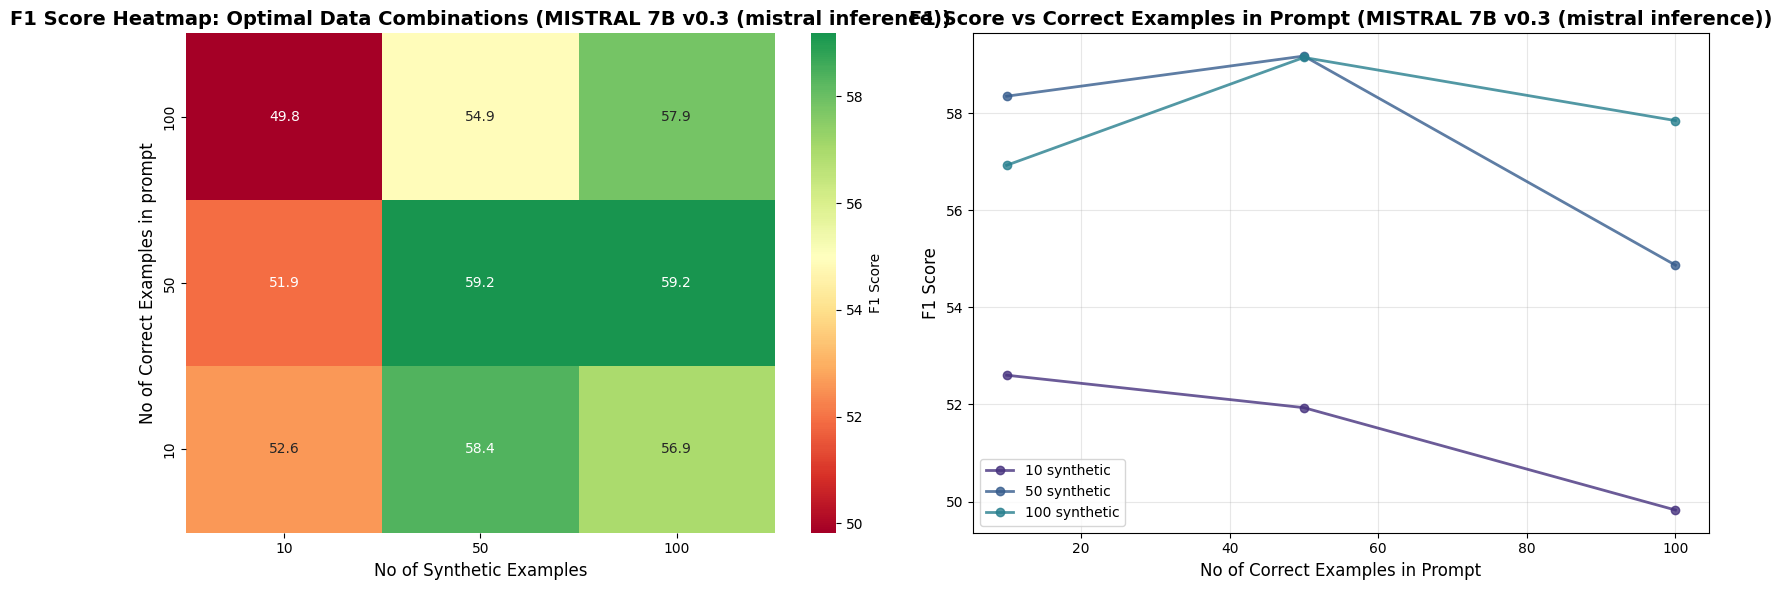

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set style for better plots
plt.style.use('default')
sns.set_palette("viridis")

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ============================================
# Plot 1: HEATMAP - Optimal Combination Zones
# ============================================

# Create pivot table for heatmap
pivot_f1 = final_no_correct_examples_df.pivot(
    index='no_corrected_train_data', 
    columns='no_syn_train_data', 
    values='f1'
)

# Create heatmap
sns.heatmap(
    pivot_f1, 
    annot=True, 
    fmt='.1f', 
    cmap='RdYlGn',
    center=55,  # Adjusted based on your data range
    ax=ax1,
    cbar_kws={'label': 'F1 Score'}
)

ax1.invert_yaxis()
ax1.set_title(f'F1 Score Heatmap: Optimal Data Combinations ({generator.model_name})', fontsize=14, fontweight='bold')
ax1.set_xlabel('No of Synthetic Examples', fontsize=12)
ax1.set_ylabel('No of Correct Examples in prompt', fontsize=12)

# ============================================
# Plot 2: TREND LINES - F1 vs Correct Examples
# ============================================

# FIX: Loop over synthetic amounts instead of corrected amounts
synthetic_amounts = sorted(final_no_correct_examples_df['no_syn_train_data'].unique())

for syn_val in synthetic_amounts:
    subset = final_no_correct_examples_df[
        final_no_correct_examples_df['no_syn_train_data'] == syn_val
    ]
    
    # Sort by correct examples for clean lines
    subset_sorted = subset.sort_values('no_corrected_train_data')
    
    ax2.plot(
        subset_sorted['no_corrected_train_data'],  # X: correct examples in prompt
        subset_sorted['f1'],                       # Y: F1 score
        marker='o', 
        markersize=6,
        linewidth=2,
        label=f'{syn_val} synthetic',
        alpha=0.8
    )

ax2.set_title(f'F1 Score vs Correct Examples in Prompt ({generator.model_name})', fontsize=14, fontweight='bold')
ax2.set_xlabel('No of Correct Examples in Prompt', fontsize=12)
ax2.set_ylabel('F1 Score', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

# Remove the incorrect threshold line (46 is way below your data)
# ax2.axhline(y=55, color='red', linestyle='--', alpha=0.5, label='Target F1')

plt.tight_layout()

plt.savefig("../results/mistral/mistral_test1.png")

plt.show()

In [12]:
display(final_no_correct_examples_df)

import pickle
with open('../results/mistral/mistral_test1.pkl', 'wb') as file:
    pickle.dump(final_no_correct_examples_df, file)

,no_corrected_train_data,no_syn_train_data,f1,Gliner f1,confidence,Avg entity in generated examples (MISTRAL 7B v0.3 (mistral inference)),avg_input_tokens,model_input_output,avg_output_tokens
0,10,10,52.603635,52.60%,95.720193,6.70,1640.333333,"(32768, 800)",296.833333
1,10,50,58.353365,58.35%,96.623031,6.78,1640.750000,"(32768, 800)",313.900000
2,10,100,56.929895,56.94%,95.567292,6.60,1640.740000,"(32768, 800)",312.380000
3,50,10,51.934287,51.93%,95.134548,6.60,6454.900000,"(32768, 800)",290.200000
4,50,50,59.181470,59.18%,96.459612,7.10,6454.809524,"(32768, 800)",319.833333
5,50,100,59.151895,59.17%,96.066611,6.96,6454.740000,"(32768, 800)",315.420000
6,100,10,49.824772,49.83%,95.517059,7.10,12488.100000,"(32768, 800)",402.600000
7,100,50,54.871379,54.88%,96.071289,7.48,12487.775000,"(32768, 800)",367.000000
8,100,100,57.850780,57.85%,96.759950,7.80,12487.882353,"(32768, 800)",352.686275
